<h1 align="center">Life Satisfaction Prediction using GDP per Capita
</h1>

##### Asignment note

This assignment is not intended to be a full project. It serves as a follow up to reinforce the concepts we have covered in lecture so
far. More comprehensive analyses and detailed projects will be introduced as we progress further into the course.

### 🎓 Learning objectives

- Load and visualize real-world data.
- Train and compare regression models using Scikit-Learn.
- Interpret model outputs and discuss generalization.


#### Imports

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

## Part 1: Data Exploration and Visualization (20 marks)

#### Q1. Load the dataset ```lifesat.csv``` and display the first 5 rows (5 marks)

In [2]:
df = pd.read_csv("./lifesat.csv")

In [3]:
df.head()

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


In [4]:
df = df.rename(columns={
    "Country": "country",
    "GDP per capita (USD)": "gdp_per_capita",
    "Life satisfaction": "life_satisfaction"
})

#### Q2. Print basic ```info``` and ```summary statistics``` (5 marks) 

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            27 non-null     str    
 1   gdp_per_capita     27 non-null     float64
 2   life_satisfaction  27 non-null     float64
dtypes: float64(2), str(1)
memory usage: 780.0 bytes


In [6]:
df.describe()

,gdp_per_capita,life_satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


#### Q3. Display a scatter plot for ```GDP per capita``` vs ```Life Satisfaction```. Add labels, title, and discuss the observed relationship (10 marks)

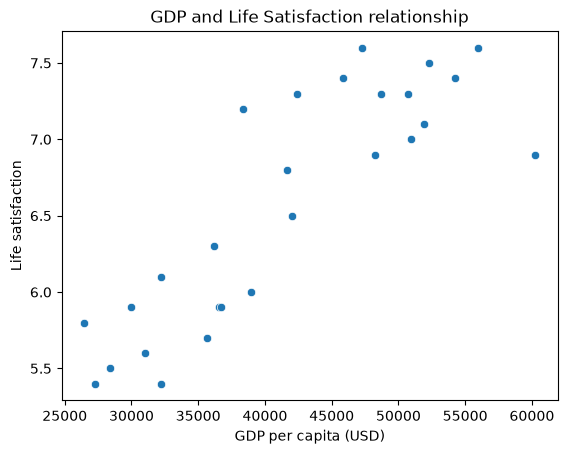

In [7]:
plt.title("GDP and Life Satisfaction relationship")
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Life satisfaction")
sns.scatterplot(
    data=df,
    x=df["gdp_per_capita"],
    y=df["life_satisfaction"]
);

#### Observed relationship

The **higher GDP per capita**, the **higher Life satisfaction**. It represents postive correlation relationship between those 2 variables (features). 

## Part 2: Linear Regression Model (30 marks)

#### Q4. Extract input (X) and target (y). Print their shapes (5 marks) 

In [8]:
X = df[["gdp_per_capita"]]
y = df["life_satisfaction"]
print(X.shape, y.shape)

(27, 1) (27,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [10]:
print(X_train.shape, y_train.shape)

(20, 1) (20,)


In [11]:
print(X_test.shape, y_test.shape)

(7, 1) (7,)


#### Q5. Train a Linear Regression model & Display coefficient and intercept (10 marks) 

In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['gdp_per_capita']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.936
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [14]:
print(model.coef_[0], model.intercept_)

6.219973474996385e-05 3.936302711267398


#### Q6. Plot the predicted regression line from the model along with a scatter plot of the data (10 marks) 

In [15]:
y_pred = model.predict(X_test)

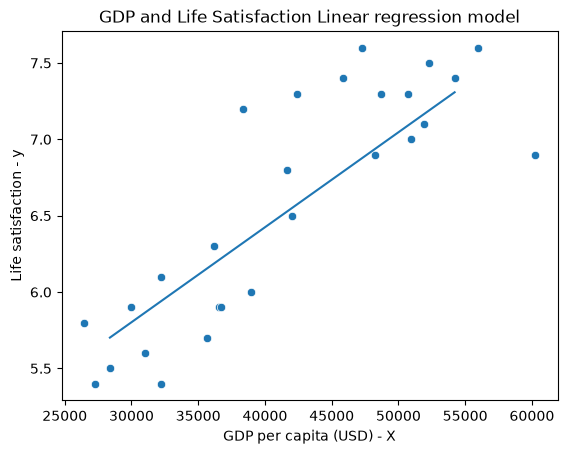

In [16]:
plt.title("GDP and Life Satisfaction Linear regression model")
plt.xlabel("GDP per capita (USD) - X")
plt.ylabel("Life satisfaction - y")
sns.lineplot(
    x = X_test.squeeze(axis = 1),
    y = y_pred
);
sns.scatterplot(
    data=df,
    x=df["gdp_per_capita"],
    y=df["life_satisfaction"]
);

#### Q7. Predict Life Satisfaction for GDP = ```37,655.2``` USD. Comment on result  (5 marks)

In [17]:
y_pred_linear = model.predict(pd.DataFrame(
    {
        "gdp_per_capita": [37_655.2]
    }
))
y_pred_linear[0]

np.float64(6.2784461632242365)

The expected **life satisfaction** in scale from 0 to 10 for country with **GDP of ```37_655.2```** is **```6.28```**

## Part 3: K-Nearest Neighbors Regression (25 marks)

#### Q8. Train a KNeighborsRegressor (n_neighbors=3) (5 marks) 

In [18]:
knn_model = KNeighborsRegressor(n_neighbors=3)

In [19]:
knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


#### Q9. (10 marks)

- Predict Life Satisfaction for GDP = 37,655.2 USD

In [20]:
y_pred_knn = knn_model.predict(pd.DataFrame(
    {
        "gdp_per_capita": [37_655.2]
    }
))
y_pred_knn[0]

np.float64(5.933333333333334)

- Compare with Linear Regression

Compared to the **Linear regression** model, **KNN** predicted a lower value for life satisfaction: **```5.93```** 

#### Q10. (10 marks)

- Use n_neighbors 1, 3, 5, and 10 and print the predicted values of life satisfaction in Q10.
- Plot the results using a line plot

In [21]:
n_neighbors = [1, 3, 5, 10]
y_n_preds = []
for n in n_neighbors:
    model = KNeighborsRegressor(n_neighbors=n).fit(X_train, y_train)
    y_pred = model.predict(
        pd.DataFrame(
            {
                "gdp_per_capita": [37_655.2]
            }
        )
    )[0]
    y_n_preds.append(y_pred)
    print(f"{n=} : {y_pred=}")

n=1 : y_pred=np.float64(5.9)
n=3 : y_pred=np.float64(5.933333333333334)
n=5 : y_pred=np.float64(5.96)
n=10 : y_pred=np.float64(6.15)


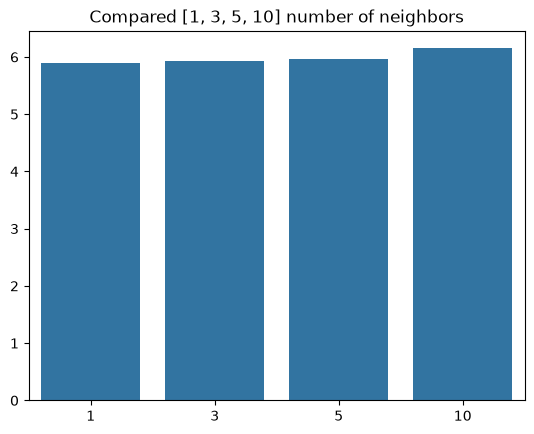

In [22]:
plt.title(f"Compared {n_neighbors} number of neighbors")
sns.barplot(
    x = n_neighbors,
    y = y_n_preds
);

Because there are only 4 values and model is KNN, barplot is more suitable to compare predicted values between models with different ```n_neighbors```